In [1]:
!pip install pandas numpy matplotlib statsmodels scikit-learn


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.5 MB 6.3 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.5 MB 5.0 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.5 MB 5.4 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.5 MB 4.6 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.5 MB 4.4 MB/s eta 0:00:02
   --------------------- ------------------ 5.2/9.5 MB 4.2 MB/s eta 0:00:02
   --------------------------- ------------ 6.6/9.5 MB 4.5 MB/s eta 0:00:01
   -------------------------------- ------- 7.9/9.5 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 5.0 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 4.9 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


PART 1 — Forecast Cumulative Confirmed Cases

C:\Users\Ayush\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Ayush\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Ayush\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Ayush\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


MAE: 575726.9665014036
RMSE: 665863.1234084895


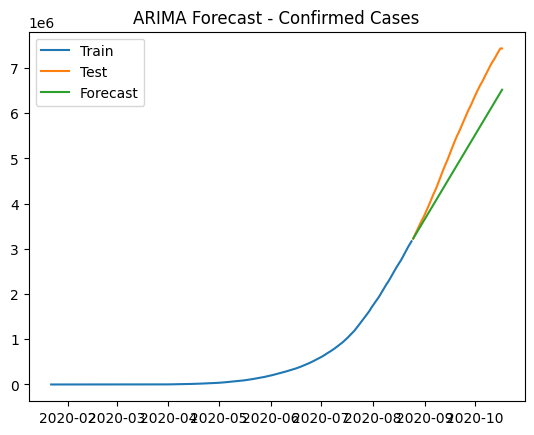

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv("data/covid_19_time_series.csv")

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Filter India (you can change country)
country = df[df['Country/Region'] == 'India']

# Set index
country = country.set_index('Date')

# Select cumulative confirmed cases
ts = country['Confirmed']

# Train-Test Split (80-20)
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

# ARIMA Model
model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))

# Evaluation
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

# Plot
plt.figure()
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(test.index, forecast, label='Forecast')
plt.title("ARIMA Forecast - Confirmed Cases")
plt.legend()
plt.show()


PART 2 — Forecast Cumulative Deaths

C:\Users\Ayush\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Ayush\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Ayush\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Ayush\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


MAE: 4590.783025235797
RMSE: 5348.845971820546


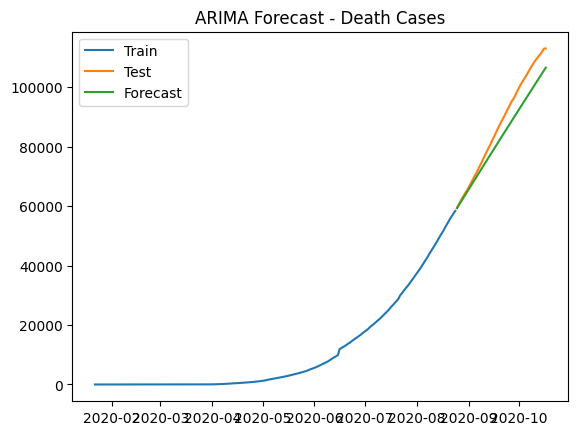

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv("data/covid_19_time_series.csv")

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Filter India (you can change country)
country = df[df['Country/Region'] == 'India']

# Set index
country = country.set_index('Date')

# Select cumulative confirmed cases
ts = country['Deaths']


# Train-Test Split (80-20)
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

# ARIMA Model
model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))

# Evaluation
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

# Plot
plt.figure()
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(test.index, forecast, label='Forecast')
plt.title("ARIMA Forecast - Death Cases")

plt.legend()
plt.show()


PART 3 — Forecast Daily New Cases (Better Model)

C:\Users\Ayush\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Ayush\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Ayush\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Ayush\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


MAE: 21198.571605983732
RMSE: 23842.74190343002


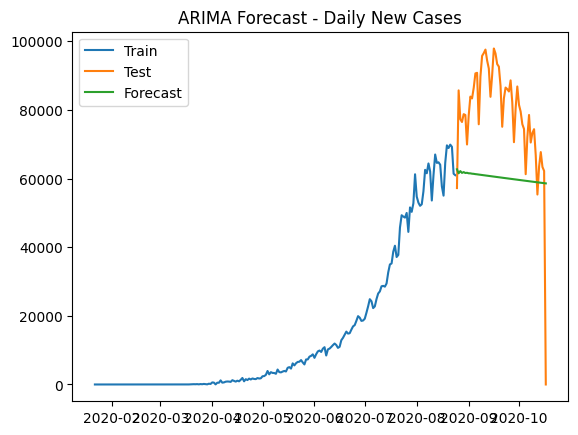

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv("data/covid_19_time_series.csv")

df['Date'] = pd.to_datetime(df['Date'])

country = df[df['Country/Region'] == 'India']
country = country.set_index('Date')

# Convert cumulative to daily new cases
country['Daily_New_Cases'] = country['Confirmed'].diff().fillna(0)

ts = country['Daily_New_Cases']

# Train-Test Split
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

# ARIMA
model = ARIMA(train, order=(2,0,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

plt.figure()
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(test.index, forecast, label='Forecast')
plt.title("ARIMA Forecast - Daily New Cases")
plt.legend()
plt.show()


WITH ACF / PACF

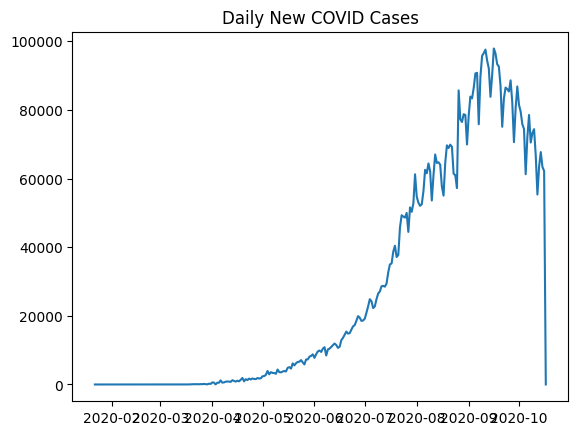

ADF Statistic: -2.800037414012573
p-value: 0.058268423942109855


<Figure size 640x480 with 0 Axes>

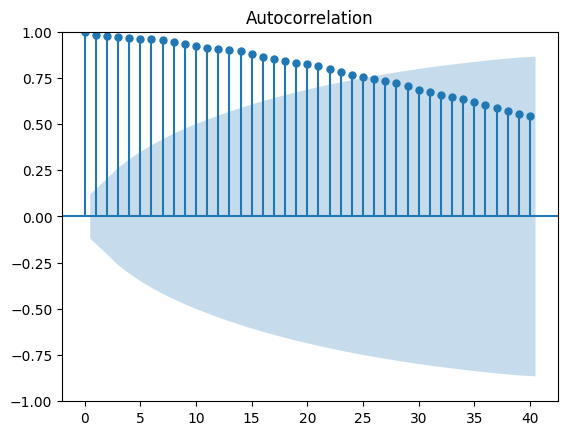

<Figure size 640x480 with 0 Axes>

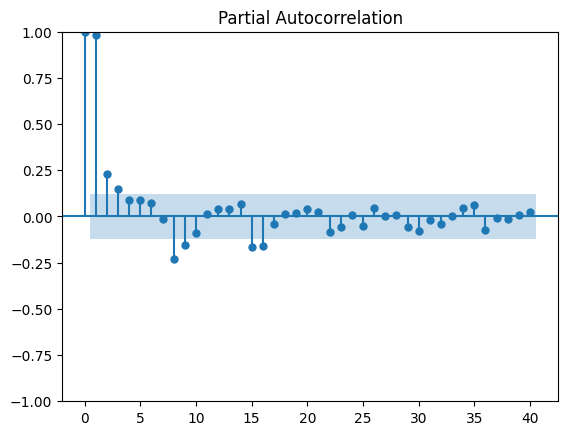

C:\Users\Ayush\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Ayush\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Ayush\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\Ayush\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


MAE: 21198.571605983732
RMSE: 23842.74190343002


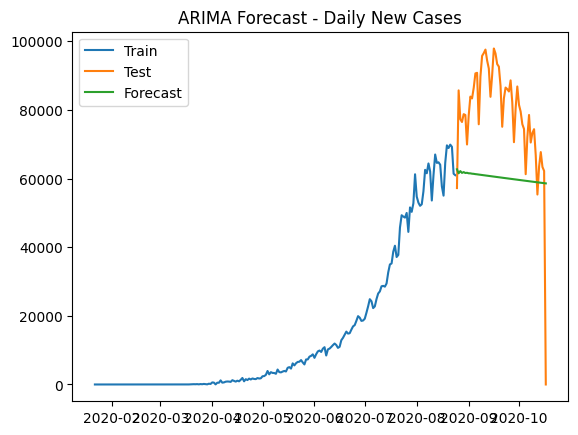

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---------------------------
# Step 1: Load Dataset
# ---------------------------
df = pd.read_csv("data/covid_19_time_series.csv")

df['Date'] = pd.to_datetime(df['Date'])

# Filter India (Change country if needed)
country = df[df['Country/Region'] == 'India']
country = country.set_index('Date')

# ---------------------------
# Step 2: Create Daily New Cases
# ---------------------------
country['Daily_New_Cases'] = country['Confirmed'].diff().fillna(0)
ts = country['Daily_New_Cases']

# ---------------------------
# Step 3: Plot Time Series
# ---------------------------
plt.figure()
plt.plot(ts)
plt.title("Daily New COVID Cases")
plt.show()

# ---------------------------
# Step 4: Check Stationarity (ADF Test)
# ---------------------------
result = adfuller(ts.dropna())
print("ADF Statistic:", result[0])
print("p-value:", result[1])

# ---------------------------
# Step 5: ACF & PACF Plots
# ---------------------------
plt.figure()
plot_acf(ts.dropna(), lags=40)
plt.show()

plt.figure()
plot_pacf(ts.dropna(), lags=40)
plt.show()

# ---------------------------
# Step 6: Train-Test Split
# ---------------------------
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

# ---------------------------
# Step 7: ARIMA Model
# ---------------------------
model = ARIMA(train, order=(2,0,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

# ---------------------------
# Step 8: Evaluation
# ---------------------------
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

print("MAE:", mae)
print("RMSE:", rmse)

# ---------------------------
# Step 9: Plot Forecast
# ---------------------------
plt.figure()
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast, label="Forecast")
plt.title("ARIMA Forecast - Daily New Cases")
plt.legend()
plt.show()
